In [81]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget


In [82]:
condition = "4mod_nocont"
checkpoint_epoch = 0
n_samples_test = 50
split = "test"


In [83]:
experiment_name = get_experiment_name(condition, "biased_00", 0)
modules = get_setup_modules('syn', experiment_name)
global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, modules=modules)
data_module = get_data_module("syn",  experiment_name, modules=modules)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
original_colors = test_samples[frozenset({'color'})]['color']
original_v_latents = test_samples[frozenset({'v_latents'})]['v_latents']
cat = test_samples[frozenset({'cat'})]['cat']

domain_mods = global_workspace.domain_mods
gw_mod = global_workspace.gw_mod
latent_domains = global_workspace.encode_domains(test_samples)

visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])
original_images_rgb = visual_module.decode_images(original_v_latents)


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/4mod_nocont_biased_00/checkpoints/last.ckpt
Weights loaded, optimizer and scheduler remain fresh!
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/4mod_nocont_biased_00/checkpoints/last.ckpt


In [84]:
# cat to position to v_latents

# cat_to_color
domain_name_source = 'cat'
domain_name_target = 'position'
latents_source = latent_domains[frozenset({domain_name_source})]

z_cat_to_position = gw_mod.encode(latents_source)[domain_name_source]
x_pred_cat_to_position = gw_mod.decode(z_cat_to_position, domains={domain_name_target})

# translation_position_to_v_latents

domain_name_source = 'position'
domain_name_target = 'v_latents'

z_cat_to_position_to_v = gw_mod.encode(x_pred_cat_to_position)[domain_name_source]
x_pred_cat_to_position_to_v = gw_mod.decode(z_cat_to_position_to_v, domains={domain_name_target})


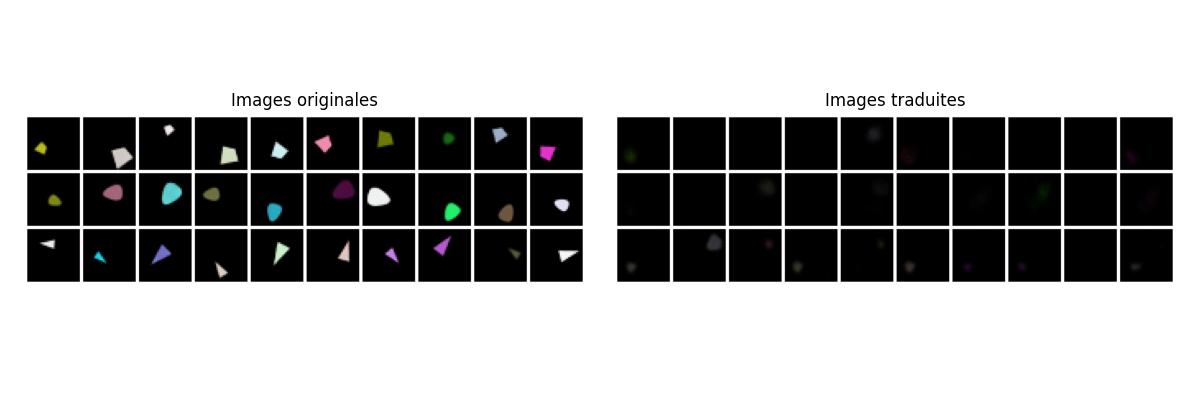

In [85]:
# fustion:cat + color to v_latents
latents_source = latent_domains[frozenset({'color', 'cat', 'position', 'v_latents'})]
p = 0.5

gw_latents = gw_mod.encode(latents_source)
z = 1*gw_latents['color'] + 1*gw_latents['cat']

x_pred_cat_color_to_v = gw_mod.decode(z, domains={'v_latents'})['v_latents']
decoded_images_f = visual_module.decode_images(x_pred_cat_color_to_v)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_f, cat, 10))
plt.show()


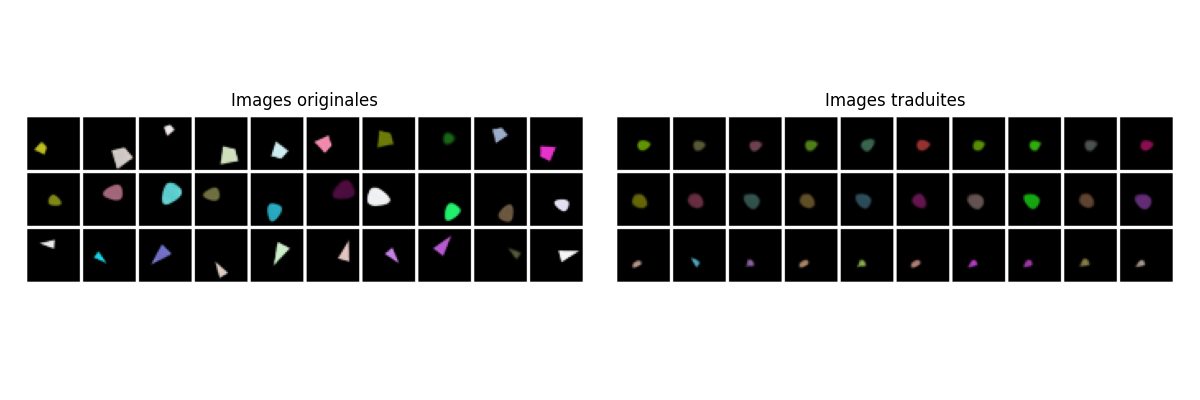

In [86]:
p = 0.5
t = 1*x_pred_cat_color_to_v+ 1*x_pred_cat_to_position_to_v['v_latents']
decoded_images_t= visual_module.decode_images(t)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_t, cat, 10))
plt.show()


In [87]:
# del original_images_rgb
# del decoded_images_dcy
# del decoded_images_f
# del decoded_images_t
# del decoded_images_dt
# torch.cuda.empty_cache()